In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 设置中文显示（必加，避免乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

In [4]:
file_path = r'plot_box.csv'

df = pd.read_csv(
    file_path,
    encoding='utf-8'
)

df

,商品ID,销量,单价(元),利润(元),品类
0,1001,20,2999,598,手机
1,1002,25,2999,748,手机
2,1003,18,2999,448,手机
3,1004,30,1999,398,耳机
4,1005,22,1999,348,耳机
5,1006,19,1999,298,耳机
6,1007,28,199,38,卫衣
7,1008,35,199,58,卫衣
8,1009,40,199,78,卫衣
9,1010,15,199,28,卫衣


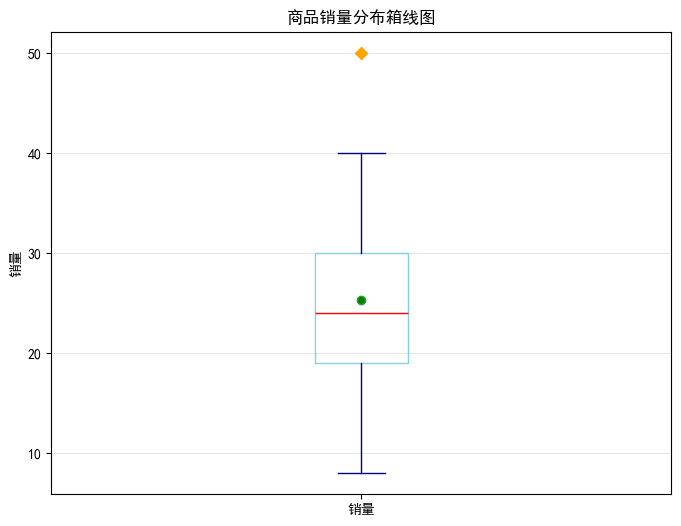

In [8]:
# 绘制箱线图
df['销量'].plot(
    kind='box',
    figsize=(8, 6),
    title='商品销量分布箱线图',
    # 只保留支持的4个键
    color={'boxes': 'skyblue',
           'whiskers': 'darkblue',
           'medians': 'red',
           'caps': 'darkblue'  # 箱线两端的横线，必须加上
    },
    showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'green'},
    # 单独设置异常值（fliers）样式
    flierprops={'marker':'D', 'markerfacecolor':'orange', 'markeredgecolor':'orange'}
)

plt.ylabel('销量')
plt.grid(axis='y', alpha=0.3)
plt.show()

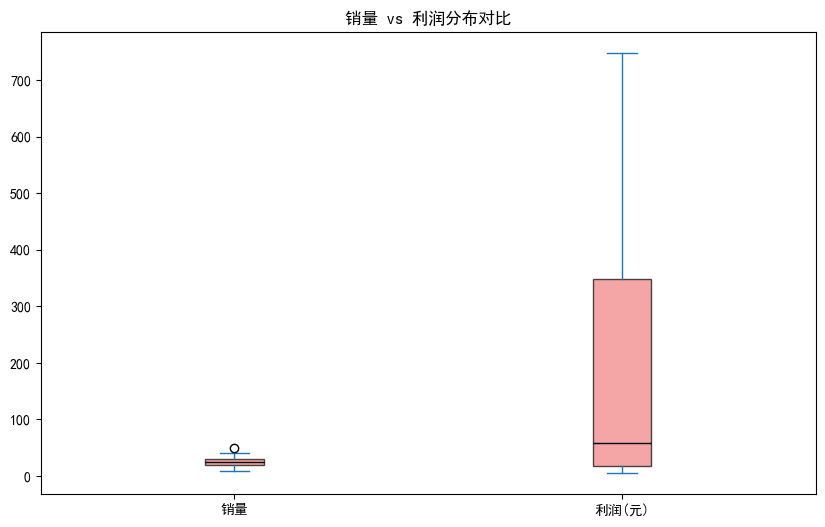

In [10]:
df[['销量', '利润(元)']].plot(
    kind='box',
    figsize=(10, 6),
    title='销量 vs 利润分布对比',
    patch_artist=True,  # 填充箱体颜色
    boxprops={'facecolor':'lightcoral', 'alpha':0.7},
    medianprops={'color':'black'})
plt.show()

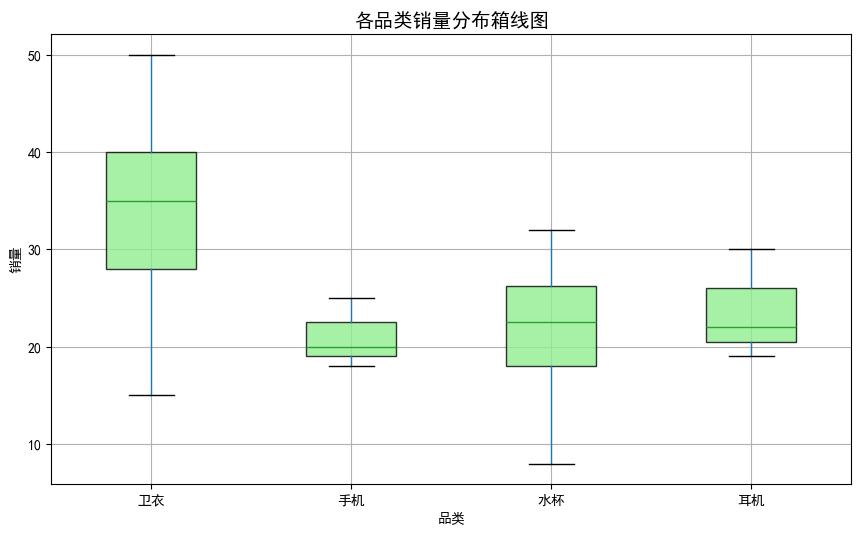

In [14]:
df.boxplot(
    column='销量',          # 分析销量
    by='品类',              # 按品类分组
    figsize=(10, 6),
    patch_artist=True,
    boxprops={'facecolor':'lightgreen', 'alpha':0.8},
    flierprops={'marker':'*', 'markersize':8},  # 异常值标记
)

# 标题移到这里设置 ✅
plt.title('各品类销量分布箱线图', fontsize=14)
plt.suptitle('')  # 清空自动生成的总标题，避免重复
plt.xlabel('品类')
plt.ylabel('销量')
plt.show()

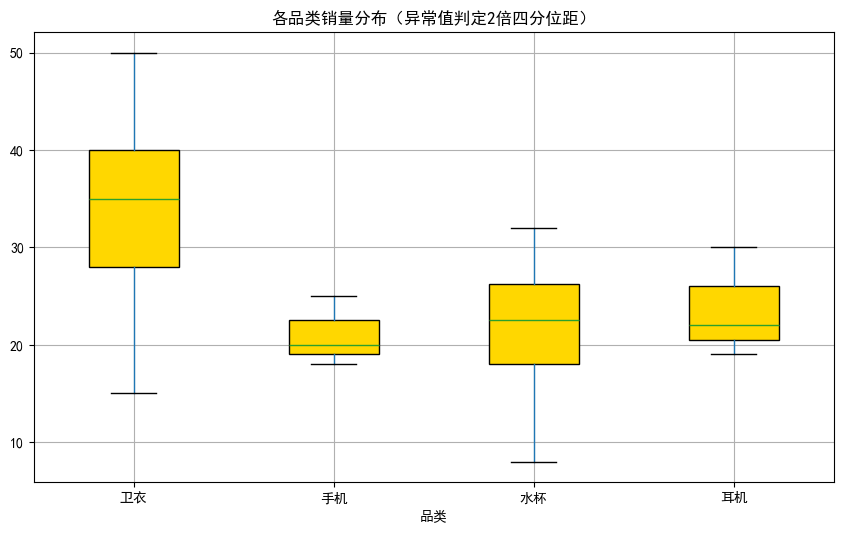

In [15]:
boxplot = df.boxplot(
    column='销量',
    by='品类',
    figsize=(10, 6),
    whis=2.0,  # 异常值判定倍数（whis=2.0）
    patch_artist=True,
    boxprops={'facecolor':'gold'}
)
plt.suptitle('')
plt.title('各品类销量分布（异常值判定2倍四分位距）')
plt.show()

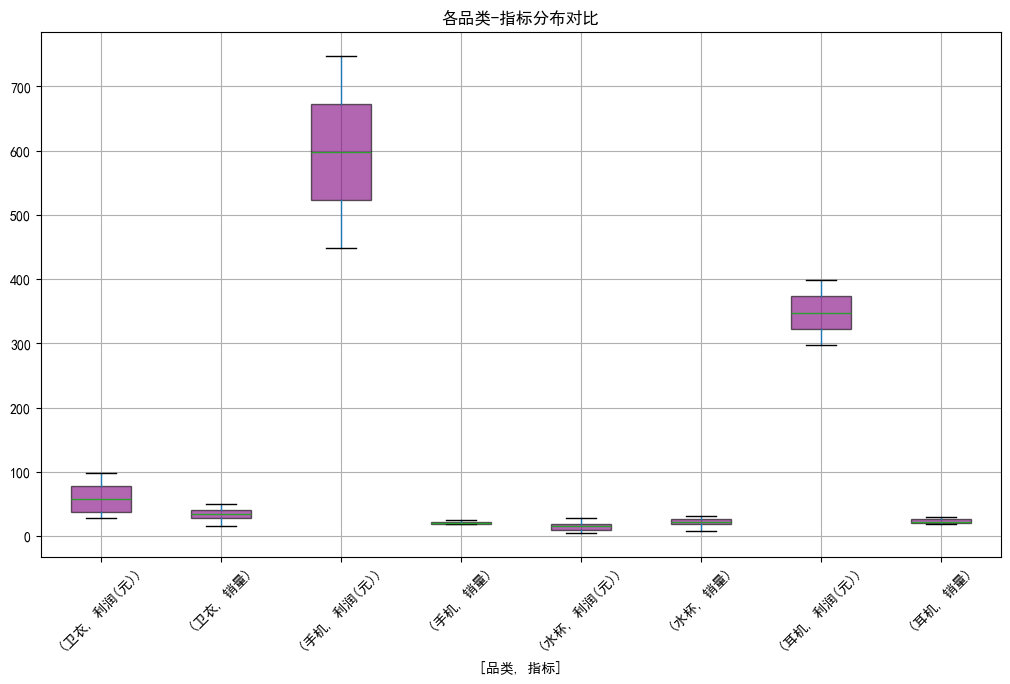

In [16]:
df_melt = pd.melt(
    df,
    id_vars=['品类'],
    value_vars=['销量', '利润(元)'],
    var_name='指标',
    value_name='数值')
df_melt.boxplot(
    column='数值',
    by=['品类', '指标'],
    figsize=(12, 7),
    patch_artist=True,
    boxprops={'facecolor':'purple', 'alpha':0.6})
plt.suptitle('')
plt.title('各品类-指标分布对比')
plt.xticks(rotation=45)  # x轴标签旋转，避免重叠
plt.show()

In [17]:
def get_boxplot_stats(df, col):
    stats = df[col].describe()
    q1 = stats['25%']
    q3 = stats['75%']
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return {'中位数': stats['50%'],'四分位距': iqr,'异常值下限': lower,'异常值上限': upper,'异常值数量': len(df[(df[col]<lower) | (df[col]>upper)])}
# 输出销量统计信息
sales_stats = get_boxplot_stats(df, '销量')
print("\n销量箱线图统计信息：")
for k, v in sales_stats.items():
    print(f"{k}：{v}")


销量箱线图统计信息：
中位数：24.0
四分位距：11.0
异常值下限：2.5
异常值上限：46.5
异常值数量：1


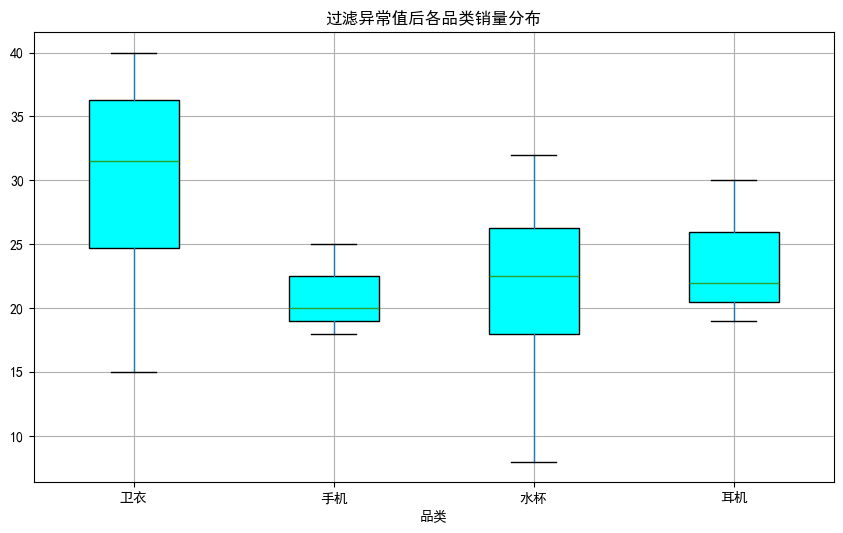

In [18]:
lower = sales_stats['异常值下限']
upper = sales_stats['异常值上限']
df_filtered = df[(df['销量'] >= lower) & (df['销量'] <= upper)]
df_filtered.boxplot(
    column='销量',
    by='品类',
    figsize=(10, 6),
    patch_artist=True,
    boxprops={'facecolor':'cyan'})
plt.suptitle('')
plt.title('过滤异常值后各品类销量分布')
plt.show()